In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

In [2]:
#Load dataset

df = pd.read_csv(r"C:\Users\yasha\Downloads\cic-ids\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
print("Initial shape:", df.shape)
print(df.head())
# Clean column names by removing leading/trailing spaces
df.columns = df.columns.str.strip()

Initial shape: (225745, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             6                       6   
2                             6                       6   
3                   

In [3]:
#Drop unnecessary columns

to_drop = ["Flow ID", "Source IP", "Destination IP", "Timestamp"]
df.drop([col for col in to_drop if col in df.columns], axis=1, inplace=True)

In [4]:
#Handle nan values and infinite values

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print("After cleaning:", df.shape)

After cleaning: (225711, 79)


In [5]:
#Encode Target Column
encoder = LabelEncoder()
df["Label"] = encoder.fit_transform(df["Label"])
print("Classes:", encoder.classes_)
     

Classes: ['BENIGN' 'DDoS']


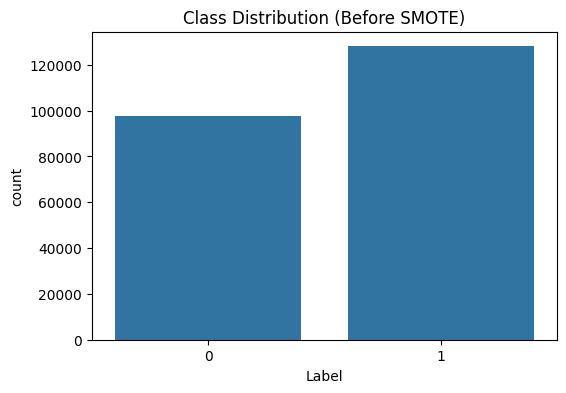

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Label"])
plt.title("Class Distribution (Before SMOTE)")
plt.show()


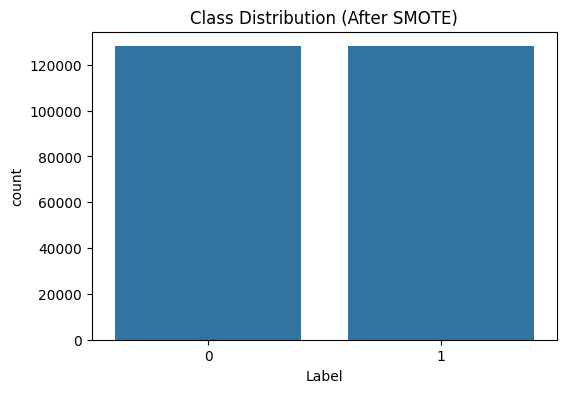

In [7]:
#Split target and features

X = df.drop("Label", axis=1)
y = df["Label"]

# Handle class imbalance
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

plt.figure(figsize=(6,4))
sns.countplot(x=y_res)
plt.title("Class Distribution (After SMOTE)")
plt.show()

In [8]:
#Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

In [9]:
##Split train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_res, test_size=0.2, random_state=42, stratify=y_res
)

In [10]:
# Dimensionality reduction

pca = PCA(n_components=20, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        solver='lbfgs',
        C=1.0,
        n_jobs=-1
    ),

    "Stochastic Gradient Descent (SGDClassifier)": SGDClassifier(
        loss='log_loss',       
        learning_rate='optimal',
        alpha=0.0001,
        max_iter=2000,
        penalty='l2'
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=15,
        min_samples_split=5,
        criterion='gini'
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        n_jobs=-1
    ),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        tree_method='hist'
    )
}

# Train & Evaluate All Models

for name, model in models.items():
    print("\n")
    print(f"Training {name}...")
    model.fit(X_train_pca, y_train)

    preds = model.predict(X_test_pca)
    acc = accuracy_score(y_test, preds)

    print(f"{name} Accuracy: {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, preds))




Training Logistic Regression...
Logistic Regression Accuracy: 99.28%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     25605
           1       0.99      1.00      0.99     25605

    accuracy                           0.99     51210
   macro avg       0.99      0.99      0.99     51210
weighted avg       0.99      0.99      0.99     51210



Training Stochastic Gradient Descent (SGDClassifier)...
Stochastic Gradient Descent (SGDClassifier) Accuracy: 98.87%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     25605
           1       0.98      1.00      0.99     25605

    accuracy                           0.99     51210
   macro avg       0.99      0.99      0.99     51210
weighted avg       0.99      0.99      0.99     51210



Training Decision Tree...
Decision Tree Accuracy: 99.97%

Classification Report:
              precision  

In [12]:
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
import pandas as pd
import numpy as np

def get_metrics(model, X, y):
    preds = model.predict(X)

    # Probability or decision scores for AUC
    try:
        probs = model.predict_proba(X)[:, 1]
    except:
        try:
            probs = model.decision_function(X)
        except:
            probs = None

    accuracy = accuracy_score(y, preds)
    sensitivity = recall_score(y, preds)

    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    specificity = tn / (tn + fp)

    f1 = f1_score(y, preds)
    auc = roc_auc_score(y, probs) if probs is not None else np.nan

    return accuracy, sensitivity, specificity, f1, auc


# Collect TRAIN and TEST metrics separately
train_rows = []
test_rows = []

for name, model in models.items():
    print(f"Evaluating {name}...")

    # TRAIN metrics
    tr_acc, tr_sens, tr_spec, tr_f1, tr_auc = get_metrics(model, X_train_pca, y_train)
    train_rows.append([
        name,
        f"{tr_acc*100:.2f}%",
        f"{tr_sens*100:.2f}%",
        f"{tr_spec*100:.2f}%",
        f"{tr_f1*100:.2f}%",
        f"{tr_auc:.4f}" if not np.isnan(tr_auc) else "NA"
    ])

    # TEST metrics
    te_acc, te_sens, te_spec, te_f1, te_auc = get_metrics(model, X_test_pca, y_test)
    test_rows.append([
        name,
        f"{te_acc*100:.2f}%",
        f"{te_sens*100:.2f}%",
        f"{te_spec*100:.2f}%",
        f"{te_f1*100:.2f}%",
        f"{te_auc:.4f}" if not np.isnan(te_auc) else "NA"
    ])

train_df = pd.DataFrame(train_rows, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
])

train_df = train_df.sort_values(by="Accuracy", ascending=False)
train_df.reset_index(drop=True, inplace=True)

print("\n TRAIN METRICS \n")
display(train_df)


test_df = pd.DataFrame(test_rows, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
])

test_df = test_df.sort_values(by="Accuracy", ascending=False)
test_df.reset_index(drop=True, inplace=True)

print("\n TEST METRICS \n")
display(test_df)


Evaluating Logistic Regression...
Evaluating Stochastic Gradient Descent (SGDClassifier)...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating Naive Bayes...
Evaluating XGBoost...

 TRAIN METRICS 



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,Logistic Regression,99.29%,99.88%,98.70%,99.29%,0.9994
1,Stochastic Gradient Descent (SGDClassifier),98.87%,99.86%,97.88%,98.88%,0.9994
2,Naive Bayes,83.79%,94.98%,72.60%,85.42%,0.9590
3,Decision Tree,100.00%,100.00%,100.00%,100.00%,1.0000
4,Random Forest,100.00%,100.00%,100.00%,100.00%,1.0000
5,XGBoost,100.00%,100.00%,100.00%,100.00%,1.0000



 TEST METRICS 



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,Random Forest,99.98%,99.96%,99.99%,99.98%,1.0000
1,XGBoost,99.98%,99.98%,99.98%,99.98%,1.0000
2,Decision Tree,99.97%,99.98%,99.96%,99.97%,0.9997
3,Logistic Regression,99.28%,99.86%,98.70%,99.28%,0.9993
4,Stochastic Gradient Descent (SGDClassifier),98.87%,99.84%,97.89%,98.88%,0.9993
5,Naive Bayes,83.78%,94.98%,72.58%,85.41%,0.9585


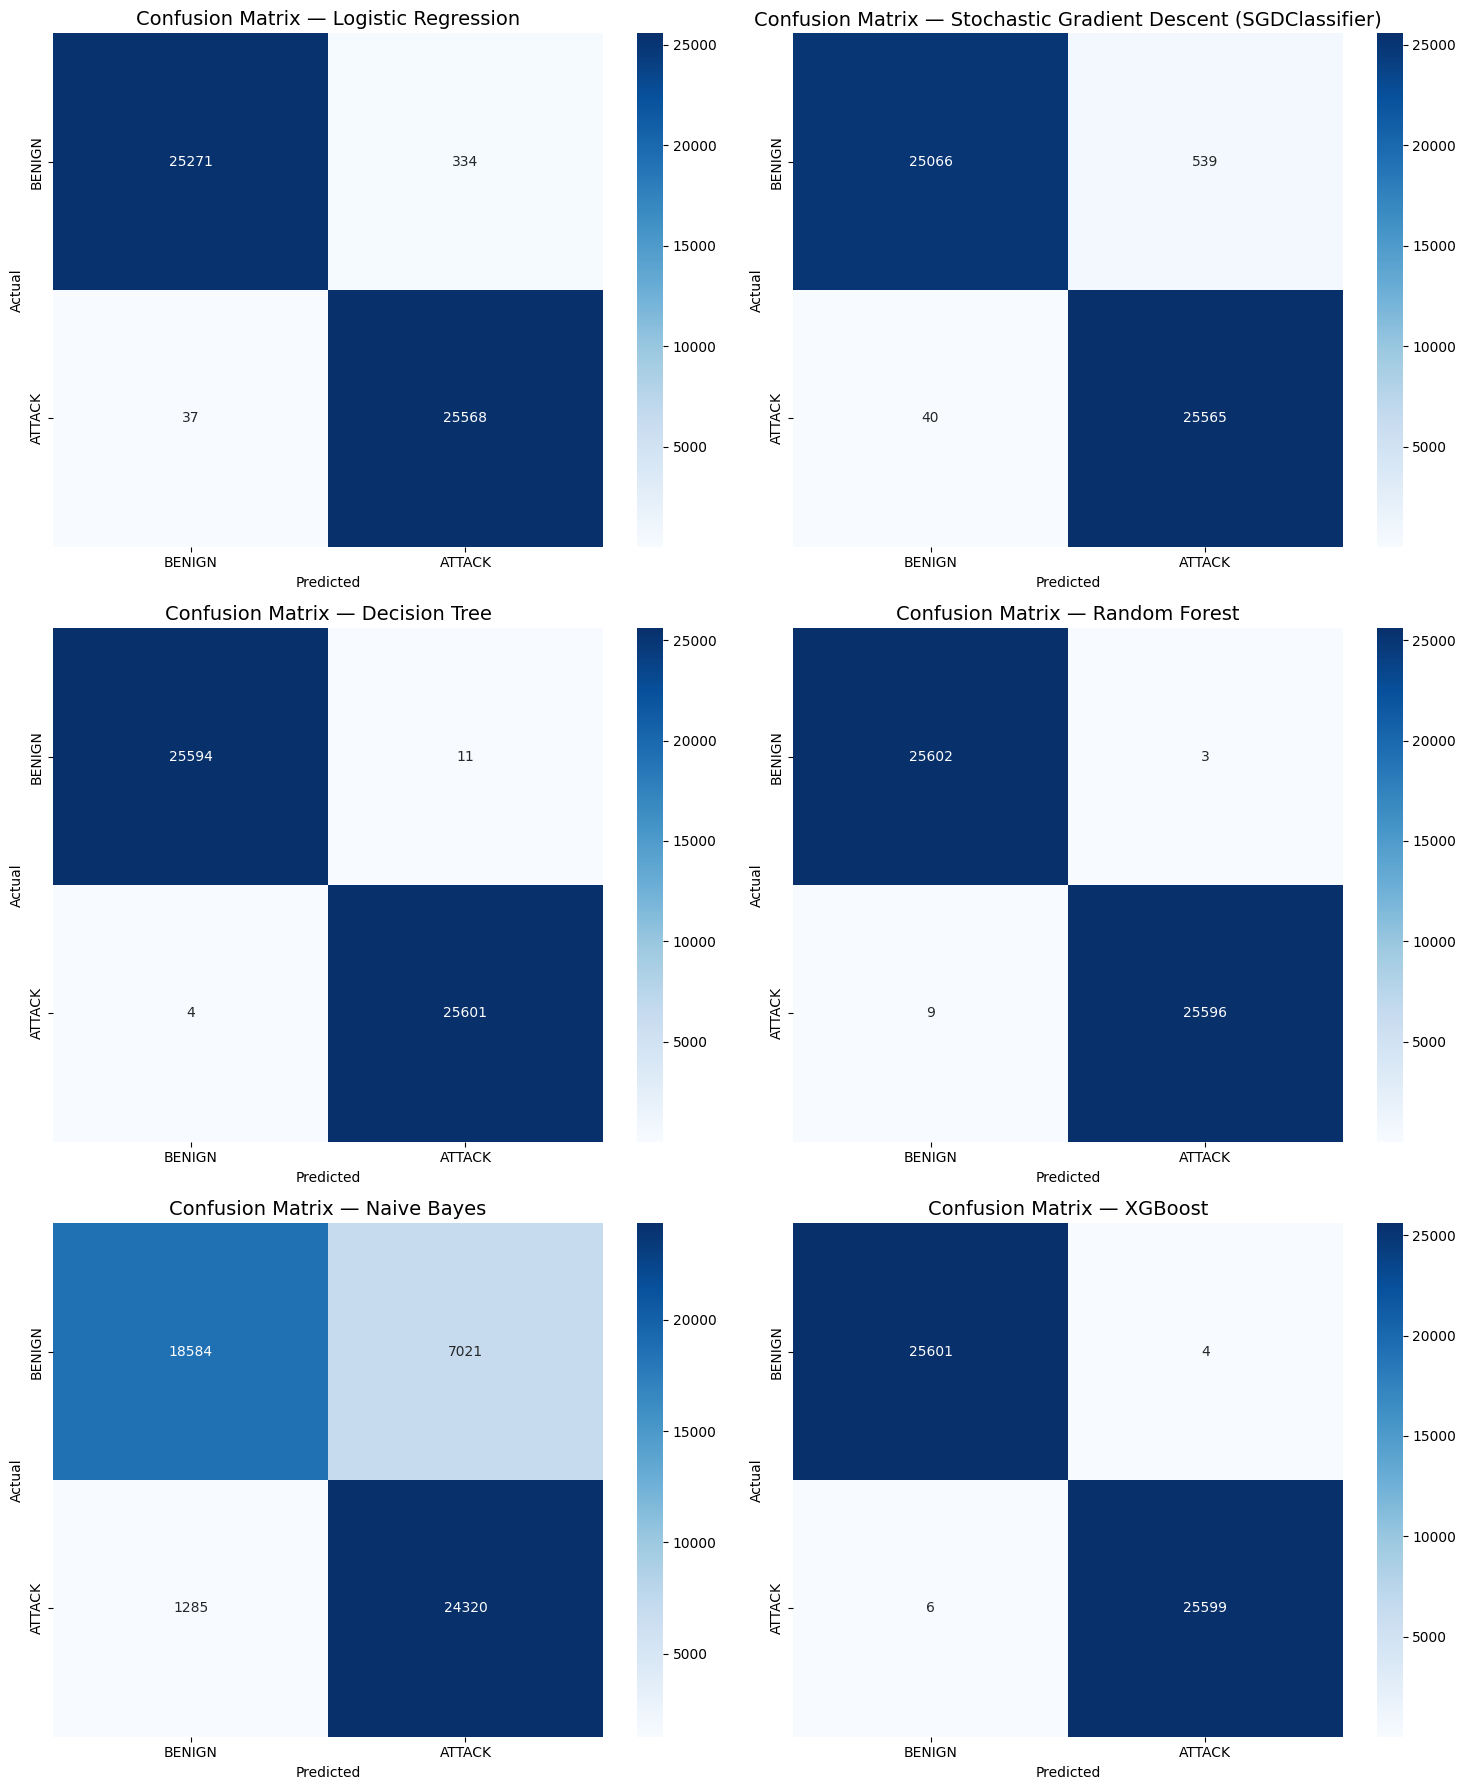

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import math

binary_model_list = list(models.items())
num_models = len(binary_model_list)

cols = 2   # <<< 2 per row
rows = math.ceil(num_models / cols)

plt.figure(figsize=(15, 6 * rows))

plot_index = 1

for name, model in binary_model_list:
    preds = model.predict(X_test_pca)
    cm = confusion_matrix(y_test, preds)

    plt.subplot(rows, cols, plot_index)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["BENIGN", "ATTACK"],
        yticklabels=["BENIGN", "ATTACK"]
    )

    plt.title(f"Confusion Matrix — {name}", fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plot_index += 1

plt.tight_layout()
plt.show()


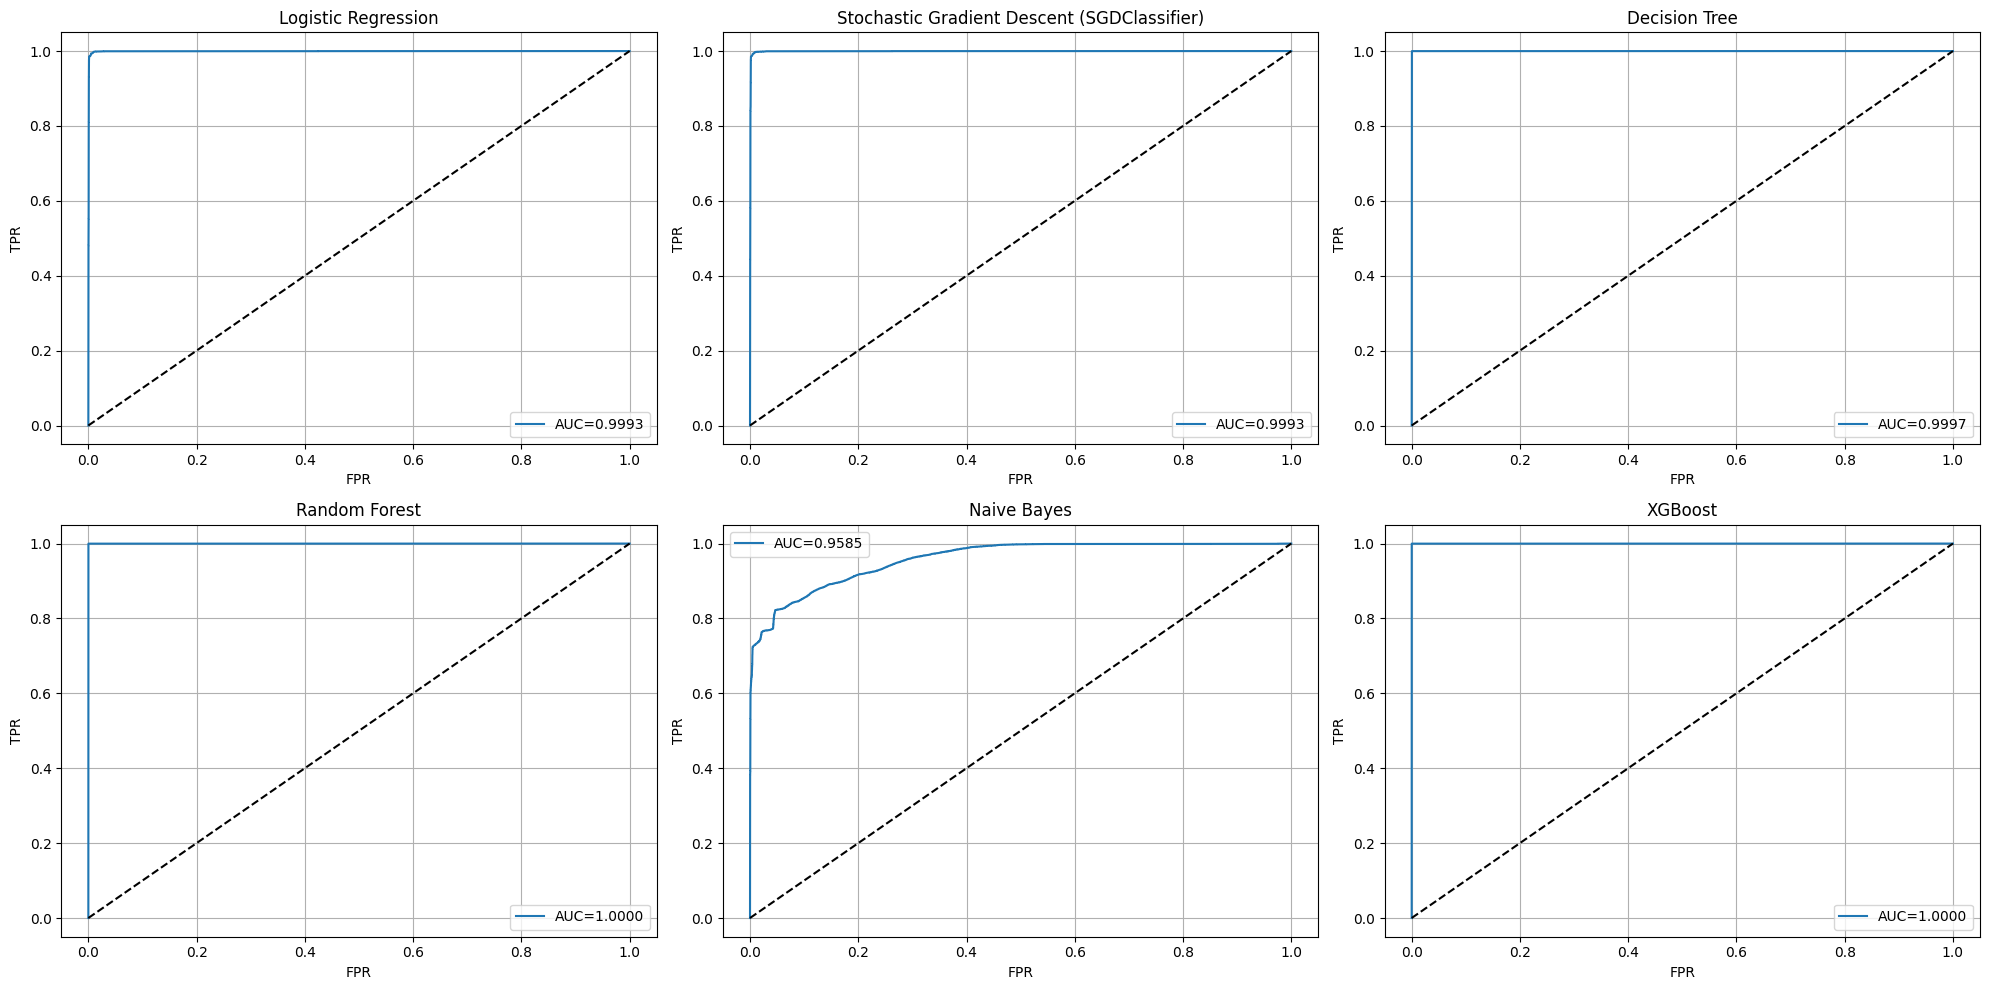

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import math

binary_model_list = list(models.items())
num_models = len(binary_model_list)

cols = 3   # <<< 3 per row
rows = math.ceil(num_models / cols)

plt.figure(figsize=(20, 5 * rows))

plot_index = 1

for name, model in binary_model_list:
    plt.subplot(rows, cols, plot_index)

    try:
        probs = model.predict_proba(X_test_pca)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probs)
        auc = roc_auc_score(y_test, probs)

        plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
        plt.plot([0,1], [0,1], 'k--')

        plt.title(name, fontsize=12)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.grid(True)
        plt.legend()

    except:
        plt.text(0.5, 0.5, "No predict_proba()", ha="center", va="center")
        plt.title(name)

    plot_index += 1

plt.tight_layout()
plt.show()


**MULTI-CLASS Classification CIC-IDS (Wednesday)**

In [15]:
# MULTI-CLASS CIC-IDS (Wednesday) — Unique Variables

mc_df = pd.read_csv(r"C:\Users\yasha\Downloads\cic-ids\Wednesday-workingHours.pcap_ISCX.csv")
print("Initial shape:", mc_df.shape)

mc_df.columns = mc_df.columns.str.strip()

# Fix label column name if corrupted
if "Label" not in mc_df.columns:
    mc_df.rename(columns={mc_df.columns[-1]: "Label"}, inplace=True)


Initial shape: (692703, 79)


In [16]:
mc_df.replace([np.inf, -np.inf], np.nan, inplace=True)
mc_df.dropna(inplace=True)
print("After cleaning:", mc_df.shape)


After cleaning: (691406, 79)


In [17]:
from sklearn.preprocessing import LabelEncoder

mc_label_encoder = LabelEncoder()
mc_df["Label"] = mc_label_encoder.fit_transform(mc_df["Label"])

print("Multi-class Labels:", mc_label_encoder.classes_)


Multi-class Labels: ['BENIGN' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest' 'DoS slowloris'
 'Heartbleed']


In [18]:
mc_X = mc_df.drop("Label", axis=1)
mc_y = mc_df["Label"]


In [19]:
from sklearn.preprocessing import StandardScaler

mc_scaler = StandardScaler()
mc_X_scaled = mc_scaler.fit_transform(mc_X)


In [20]:
from sklearn.model_selection import train_test_split

mc_X_train, mc_X_test, mc_y_train, mc_y_test = train_test_split(
    mc_X_scaled, mc_y, test_size=0.2, random_state=42, stratify=mc_y
)


In [21]:
from sklearn.decomposition import PCA

mc_pca = PCA(n_components=20, random_state=42)
mc_X_train_pca = mc_pca.fit_transform(mc_X_train)
mc_X_test_pca = mc_pca.transform(mc_X_test)


In [22]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

mc_models = {

    "MC_LogisticRegression": LogisticRegression(
        max_iter=2000,
        multi_class='multinomial',
        solver='lbfgs',
        class_weight='balanced'
    ),

    "MC_SGDClassifier": SGDClassifier(
        loss='log_loss',
        max_iter=2000,
        class_weight='balanced'
    ),

    "MC_DecisionTree": DecisionTreeClassifier(
        max_depth=20,
        class_weight='balanced'
    ),

    "MC_RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        n_jobs=-1,
        class_weight='balanced'
    ),

    "MC_NaiveBayes": GaussianNB(),

    "MC_XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        tree_method='hist'
    )
}


In [23]:
from sklearn.metrics import accuracy_score, classification_report

for mc_name, mc_model in mc_models.items():
    print("\n==============================")
    print(f"Training {mc_name}...")

    mc_model.fit(mc_X_train_pca, mc_y_train)
    mc_preds = mc_model.predict(mc_X_test_pca)

    mc_acc = accuracy_score(mc_y_test, mc_preds)
    print(f"{mc_name} Accuracy: {mc_acc*100:.2f}%\n")

    print(classification_report(
        mc_y_test, mc_preds, target_names=mc_label_encoder.classes_
    ))



Training MC_LogisticRegression...


C:\Users\yasha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


MC_LogisticRegression Accuracy: 92.65%

                  precision    recall  f1-score   support

          BENIGN       1.00      0.89      0.94     87937
   DoS GoldenEye       0.58      0.99      0.73      2059
        DoS Hulk       0.96      0.99      0.98     46025
DoS Slowhttptest       0.25      0.90      0.39      1100
   DoS slowloris       0.23      0.93      0.37      1159
      Heartbleed       0.67      1.00      0.80         2

        accuracy                           0.93    138282
       macro avg       0.61      0.95      0.70    138282
    weighted avg       0.97      0.93      0.94    138282


Training MC_SGDClassifier...
MC_SGDClassifier Accuracy: 94.96%

                  precision    recall  f1-score   support

          BENIGN       0.97      0.96      0.96     87937
   DoS GoldenEye       0.74      0.90      0.81      2059
        DoS Hulk       0.96      0.95      0.95     46025
DoS Slowhttptest       0.62      0.71      0.66      1100
   DoS slowloris     

In [24]:
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd

def get_metrics_multiclass(model, X, y):
    preds = model.predict(X)

    # Accuracy
    accuracy = accuracy_score(y, preds)

    # Sensitivity = macro recall
    sensitivity = recall_score(y, preds, average="macro")

    # F1 Score = macro
    f1 = f1_score(y, preds, average="macro")

    # Specificity calculation (macro)
    cm = confusion_matrix(y, preds)
    num_classes = cm.shape[0]
    specificities = []

    for i in range(num_classes):
        tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
        fp = cm[:,i].sum() - cm[i,i]
        specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(specificity_i)

    specificity = np.mean(specificities)

    # AUC (macro, OvR)
    try:
        probs = model.predict_proba(X)
        y_bin = label_binarize(y, classes=np.unique(y))
        auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    except:
        auc = np.nan

    return accuracy, sensitivity, specificity, f1, auc

mc_train_rows = []
mc_test_rows = []

for name, model in mc_models.items():
    print(f"Evaluating {name}...")

    # TRAIN metrics
    tr_acc, tr_sens, tr_spec, tr_f1, tr_auc = get_metrics_multiclass(
        model, mc_X_train_pca, mc_y_train
    )
    mc_train_rows.append([
        name,
        f"{tr_acc*100:.2f}%",
        f"{tr_sens*100:.2f}%",
        f"{tr_spec*100:.2f}%",
        f"{tr_f1*100:.2f}%",
        f"{tr_auc:.4f}" if not np.isnan(tr_auc) else "NA"
    ])

    # TEST metrics
    te_acc, te_sens, te_spec, te_f1, te_auc = get_metrics_multiclass(
        model, mc_X_test_pca, mc_y_test
    )
    mc_test_rows.append([
        name,
        f"{te_acc*100:.2f}%",
        f"{te_sens*100:.2f}%",
        f"{te_spec*100:.2f}%",
        f"{te_f1*100:.2f}%",
        f"{te_auc:.4f}" if not np.isnan(te_auc) else "NA"
    ])

# CREATE DATAFRAMES
mc_train_df = pd.DataFrame(mc_train_rows, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
])

mc_train_df = mc_train_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n MULTI-CLASS TRAIN METRICS \n")
display(mc_train_df)


mc_test_df = pd.DataFrame(mc_test_rows, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
])

mc_test_df = mc_test_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n MULTI-CLASS TEST METRICS \n")
display(mc_test_df)


Evaluating MC_LogisticRegression...
Evaluating MC_SGDClassifier...
Evaluating MC_DecisionTree...
Evaluating MC_RandomForest...
Evaluating MC_NaiveBayes...
Evaluating MC_XGBoost...

 MULTI-CLASS TRAIN METRICS 



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,MC_RandomForest,99.98%,99.99%,100.00%,99.98%,1.0000
1,MC_XGBoost,99.97%,99.90%,99.99%,99.90%,1.0000
2,MC_DecisionTree,99.77%,99.91%,99.95%,99.12%,0.9999
3,MC_SGDClassifier,95.02%,89.86%,98.52%,67.18%,0.9944
4,MC_LogisticRegression,92.70%,95.14%,98.60%,71.94%,0.9949
5,MC_NaiveBayes,56.57%,70.19%,89.17%,53.70%,0.9467



 MULTI-CLASS TEST METRICS 



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,MC_XGBoost,99.94%,99.52%,99.98%,99.57%,0.9998
1,MC_RandomForest,99.93%,99.47%,99.98%,99.55%,0.9993
2,MC_DecisionTree,99.71%,99.34%,99.94%,98.63%,0.9970
3,MC_SGDClassifier,94.96%,89.46%,98.50%,66.71%,0.9940
4,MC_LogisticRegression,92.65%,94.91%,98.59%,70.17%,0.9943
5,MC_NaiveBayes,56.71%,69.77%,89.20%,53.61%,0.9456


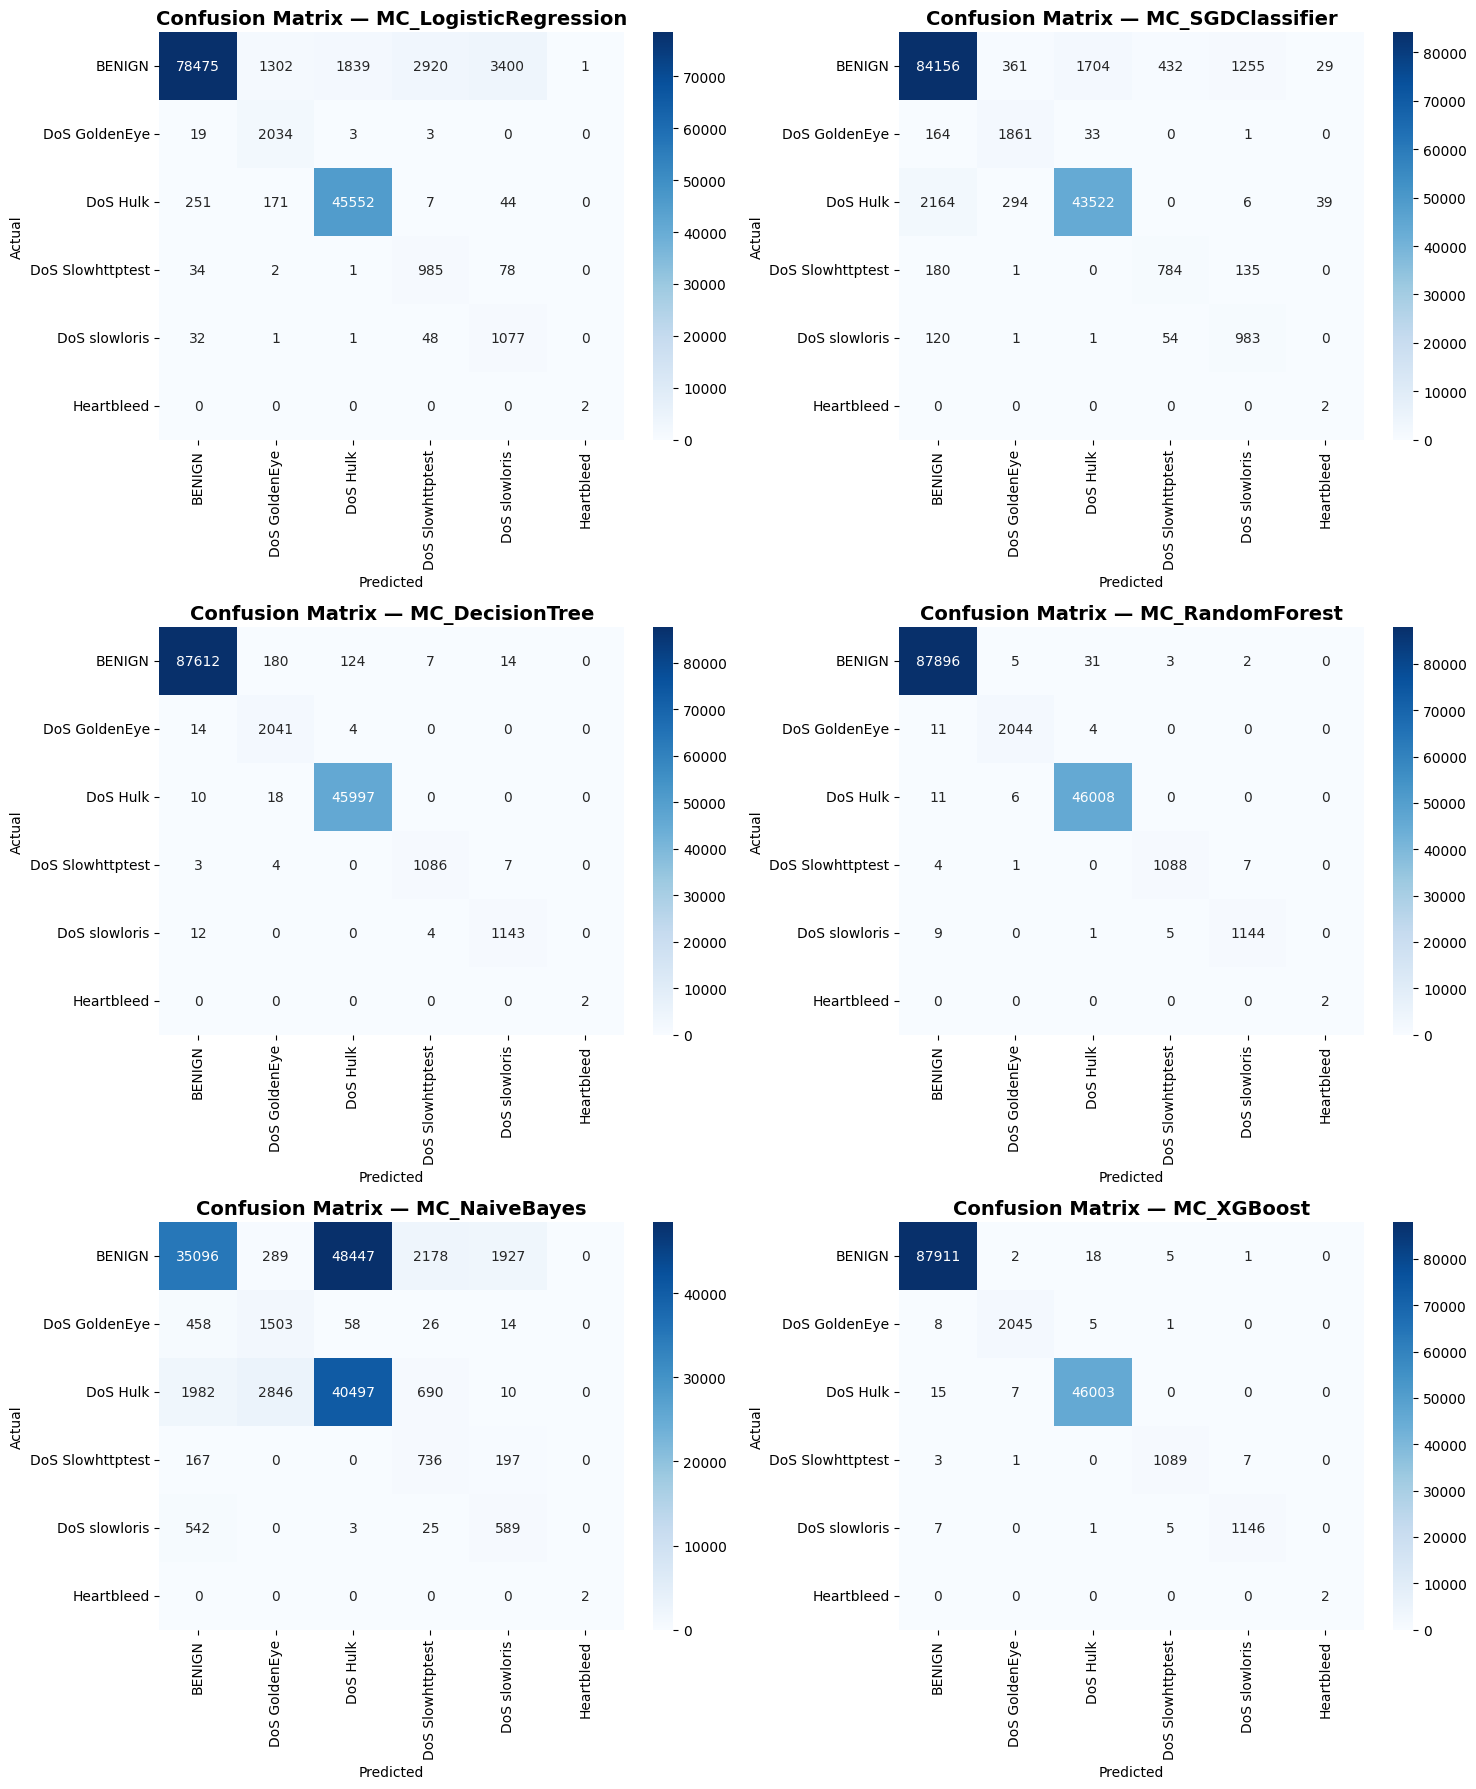

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import math

mc_model_list = list(mc_models.items())
num_models = len(mc_model_list)
cols = 2                          
rows = math.ceil(num_models / cols)

plt.figure(figsize=(15, 6 * rows))  # adjust if needed

plot_index = 1

for mc_name, mc_model in mc_model_list:
    mc_preds = mc_model.predict(mc_X_test_pca)
    mc_cm = confusion_matrix(mc_y_test, mc_preds)

    # subplot (rows x cols)
    plt.subplot(rows, cols, plot_index)

    sns.heatmap(
        mc_cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=mc_label_encoder.classes_,
        yticklabels=mc_label_encoder.classes_
    )

    plt.title(f"Confusion Matrix — {mc_name}", fontsize=14, fontweight="bold")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plot_index += 1

plt.tight_layout()
plt.show()


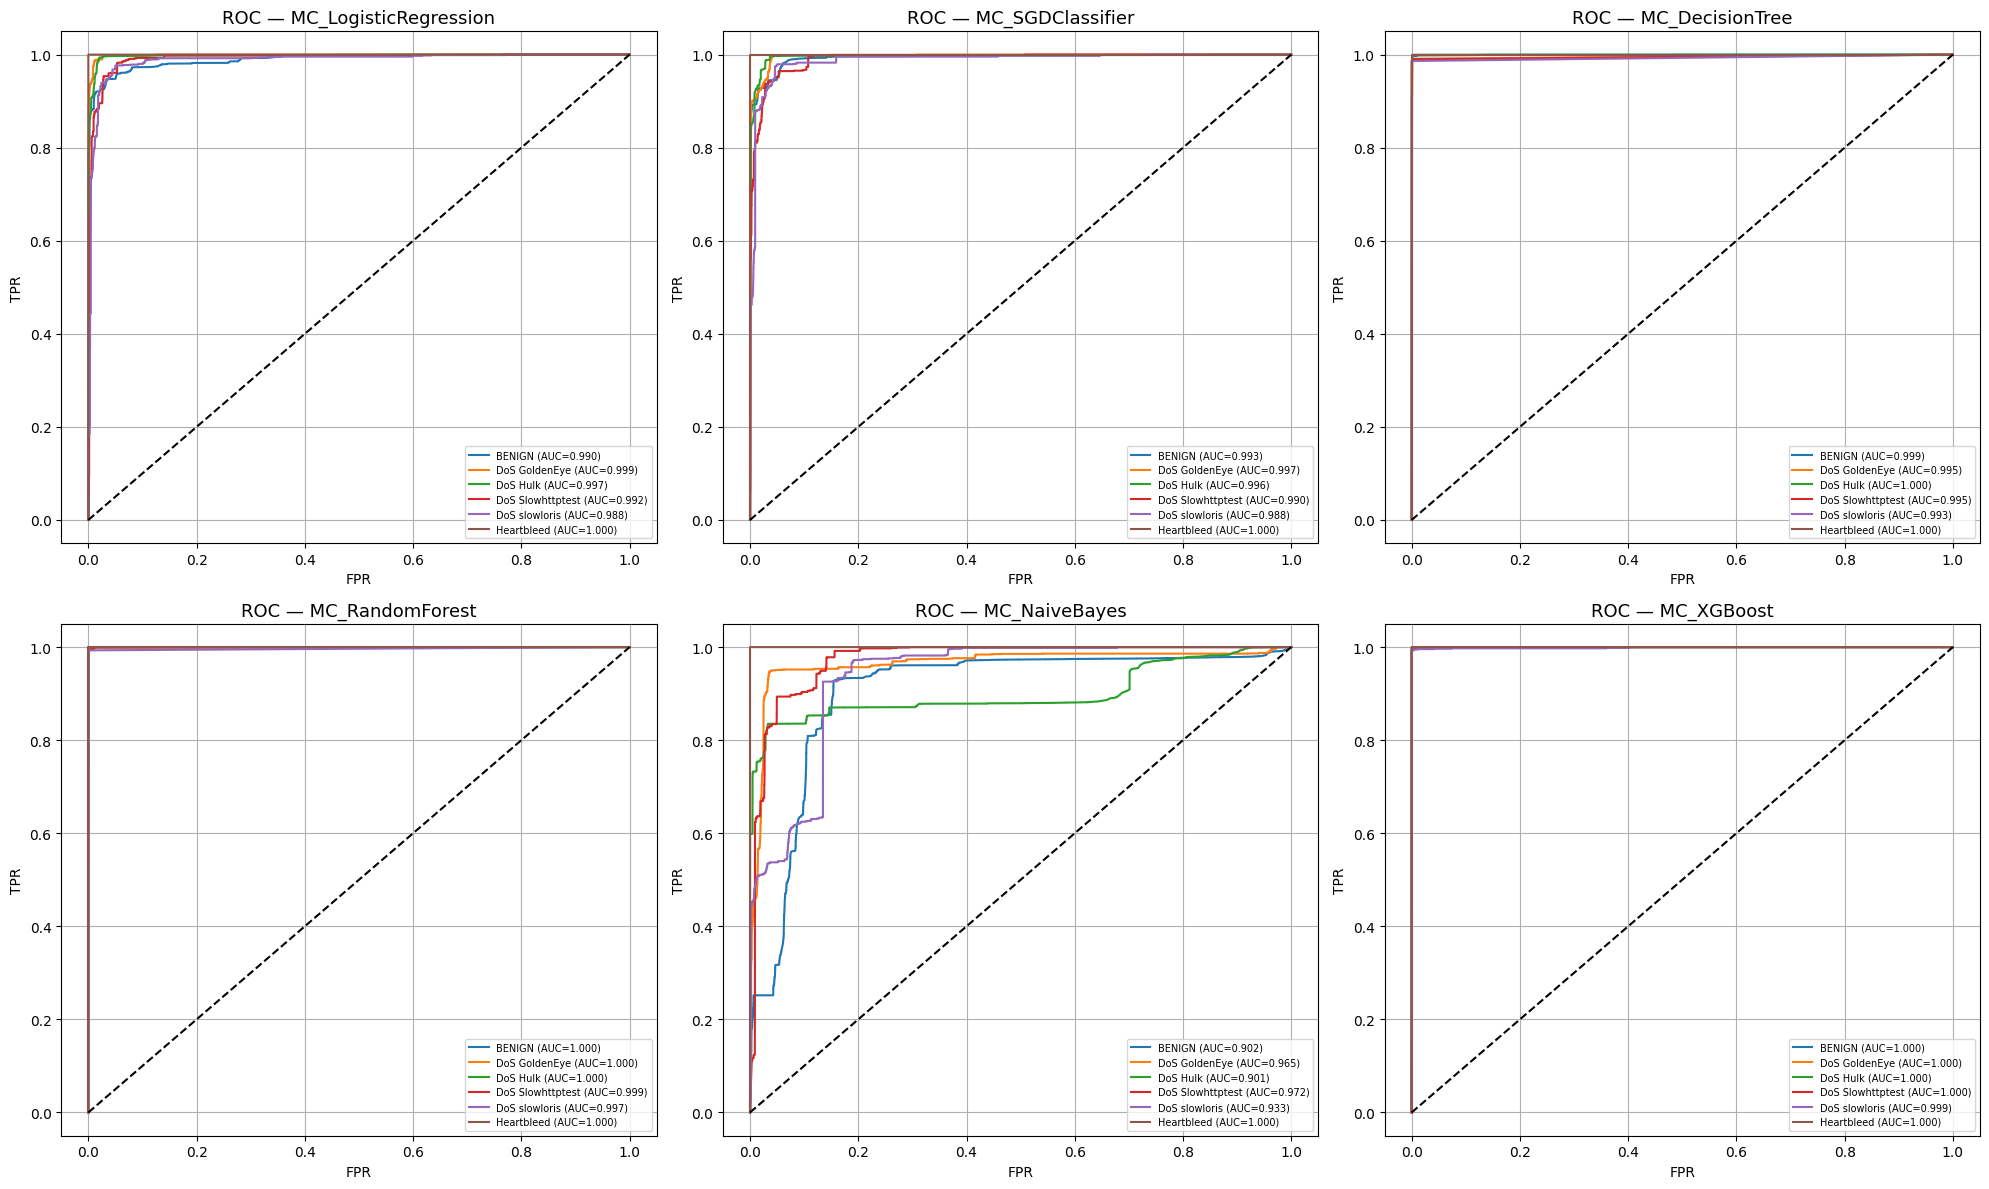

In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import math

# Convert labels to one-hot for OvR ROC
mc_y_test_bin = label_binarize(mc_y_test, classes=np.unique(mc_y_test))
n_classes = mc_y_test_bin.shape[1]
class_names = mc_label_encoder.inverse_transform(np.unique(mc_y_test))

mc_model_list = list(mc_models.items())
num_models = len(mc_model_list)

cols = 3   # <<< 3 ROC curves per row
rows = math.ceil(num_models / cols)

plt.figure(figsize=(20, 6 * rows))   # adjust as needed

plot_index = 1

for mc_name, mc_model in mc_model_list:
    try:
        mc_probs = mc_model.predict_proba(mc_X_test_pca)

        # Create subplot
        plt.subplot(rows, cols, plot_index)

        # Plot ROC for each class inside the subplot
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(mc_y_test_bin[:, i], mc_probs[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")

        plt.plot([0,1], [0,1], 'k--')
        plt.title(f"ROC — {mc_name}", fontsize=13)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.grid(True)
        plt.legend(fontsize=7)

    except Exception as e:
        plt.subplot(rows, cols, plot_index)
        plt.text(0.5, 0.5, "No predict_proba()", ha="center", va="center")
        plt.title(mc_name)

    plot_index += 1

plt.tight_layout()
plt.show()


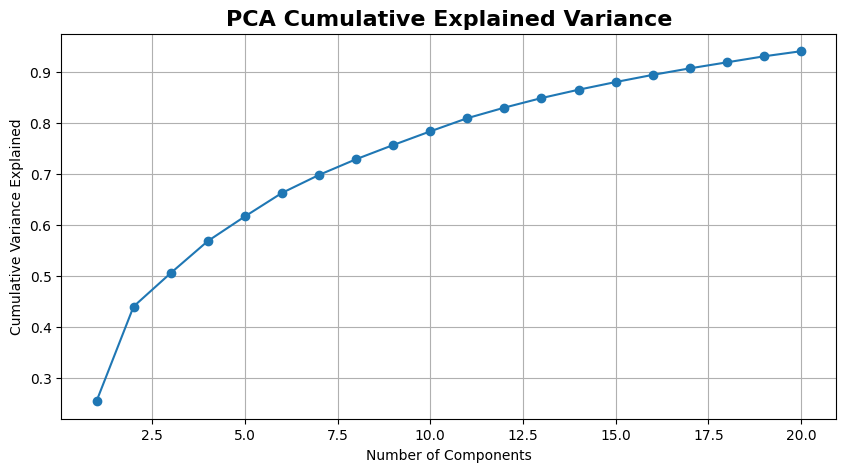

In [27]:
## PCA Explained Variance Plot

plt.figure(figsize=(10,5))
plt.plot(
    range(1, len(mc_pca.explained_variance_ratio_)+1),
    mc_pca.explained_variance_ratio_.cumsum(),
    marker='o'
)

plt.title("PCA Cumulative Explained Variance", fontsize=16, fontweight="bold")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.grid(True)
plt.show()


In [28]:
import os
import pickle

# -----------------------------------
# CREATE DIRECTORY STRUCTURE
# -----------------------------------
paths = [
    "models/cicids/binary/models",
    "models/cicids/binary/preprocess",
    "models/cicids/multiclass/models",
    "models/cicids/multiclass/preprocess"
]

for p in paths:
    os.makedirs(p, exist_ok=True)


# ===========================================================
# SAVE CIC-IDS BINARY MODELS
# ===========================================================

print("Saving CIC-IDS Binary Models...")

for name, model in models.items():
    filename = f"models/cicids/binary/models/{name.replace(' ', '_').lower()}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(model, f)

# Save binary SCALER & PCA
with open("models/cicids/binary/preprocess/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("models/cicids/binary/preprocess/pca.pkl", "wb") as f:
    pickle.dump(pca, f)

print("✔ Binary models & preprocessors saved.\n")



# ===========================================================
# SAVE CIC-IDS MULTI-CLASS MODELS
# ===========================================================

print("Saving CIC-IDS Multi-Class Models...")

for name, model in mc_models.items():
    filename = f"models/cicids/multiclass/models/{name.replace(' ', '_').lower()}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(model, f)

# Save multiclass SCALER, PCA, and Label Encoder
with open("models/cicids/multiclass/preprocess/scaler.pkl", "wb") as f:
    pickle.dump(mc_scaler, f)

with open("models/cicids/multiclass/preprocess/pca.pkl", "wb") as f:
    pickle.dump(mc_pca, f)

with open("models/cicids/multiclass/preprocess/label_encoder.pkl", "wb") as f:
    pickle.dump(mc_label_encoder, f)

print("✔ Multi-class models & preprocessors saved.\n")


print("ALL CIC-IDS MODELS SAVED SUCCESSFULLY!")


Saving CIC-IDS Binary Models...
✔ Binary models & preprocessors saved.

Saving CIC-IDS Multi-Class Models...
✔ Multi-class models & preprocessors saved.

ALL CIC-IDS MODELS SAVED SUCCESSFULLY!


In [58]:
# -------------------------------
# PREPARE BINARY TABLES
# -------------------------------

binary_train_df = train_df.copy()
binary_train_df["Set"] = "Train"
binary_train_df["Type"] = "Binary"

binary_test_df = test_df.copy()
binary_test_df["Set"] = "Test"
binary_test_df["Type"] = "Binary"

# Combine binary first (this creates the FIRST BLOCK)
binary_block = pd.concat(
    [binary_train_df, binary_test_df],
    ignore_index=True
)

# -------------------------------
# PREPARE MULTI-CLASS TABLES
# -------------------------------

mc_train_df2 = mc_train_df.copy()
mc_train_df2["Set"] = "Train"
mc_train_df2["Type"] = "Multi-Class"

mc_test_df2 = mc_test_df.copy()
mc_test_df2["Set"] = "Test"
mc_test_df2["Type"] = "Multi-Class"

# Combine multi-class (SECOND BLOCK)
multi_block = pd.concat(
    [mc_train_df2, mc_test_df2],
    ignore_index=True
)

# -------------------------------
# CONCATENATE IN ORDER
# -------------------------------

final_results_df = pd.concat(
    [binary_block, multi_block],  
    ignore_index=True
)

# -------------------------------
# SAVE FILE
# -------------------------------

final_results_df.to_json(
    "CICIDS_All_Results.json",
    orient="records",    # array of objects (clean format)
    indent=4
)

